# IEEE 118-Bus Smart Grid with KoopmanGraph

This notebook applies **KoopmanGraph** to the IEEE 118-bus transmission test case — a
standard benchmark in power-systems research. We use the real MATPOWER network
topology and bus states, then train a topology-aware Koopman model to forecast
future grid snapshots.

## Domain context (for non-experts)

A power transmission grid is a graph:

- **Buses** are nodes — connection points where loads and generators attach.
- **Branches** (transmission lines, transformers) are edges — they couple buses
  electrically so voltage and power flow propagate across the network.

Each bus carries measurable quantities. In this tutorial we track four features
per bus:

| Feature | Meaning |
|---------|---------|
| **Vm** | Voltage magnitude (per unit) — how "strong" the bus voltage is |
| **Va** | Voltage angle (degrees) — phase relative to a reference |
| **Pd** | Active power demand (per unit on system base) |
| **Qd** | Reactive power demand (per unit on system base) |

Because buses are coupled through branches, changes at one bus influence
neighbors — exactly the kind of **spatiotemporal graph dynamics** KoopmanGraph
is designed to model.

## The encode → Koopman step → decode workflow

1. **Encode:** A GNN lifts bus features into a latent space while respecting
   the transmission topology.
2. **Koopman step:** A learned matrix $K$ advances latent states linearly:
   $z_{t+1} \approx z_t K^\top$.
3. **Decode:** A GNN maps latent states back to physical bus features.

Training aligns one-step predictions with observed snapshots. Optional
forward-consistency loss encourages linear evolution in latent space.

In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

# Agg is required for headless nbmake/CI runs; interactive kernels use inline.
if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import torch
from torch_geometric.data import Data

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets import IEEE118DynamicBenchmark
from koopman_graph.training import constant_loss_weights

## Load IEEE 118-bus data

Topology and initial bus states come from the [MATPOWER](https://matpower.org/)
`case118.m` test case. On first use, KoopmanGraph downloads and caches the
parsed network under `data/ieee118/topology.pt`.

You can also refresh the cache manually:

```bash
python scripts/download_ieee118.py
```

`IEEE118DynamicBenchmark.generate` builds a spatiotemporal sequence on the real
118-bus graph: voltages diffuse along transmission lines while loads follow a
slow sinusoidal ramp (a simplified stand-in for changing grid conditions).

We use mild diffusion/decay and a small load ramp so trajectories evolve
smoothly — easier for the model to learn stable multi-step rollouts.

> **Note:** For large-scale optimal power flow snapshots, see the
> [PowerGraph dataset](https://arxiv.org/abs/2402.02827).

In [2]:
topology = IEEE118DynamicBenchmark.load_topology()
print(f"Buses: {topology['num_nodes']}")
print(f"Branches (directed edges): {topology['edge_index'].shape[1]}")
print(f"System base MVA: {topology['base_mva']}")

data_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=20 if os.environ.get("PYTEST_CURRENT_TEST") else 40,
    seed=42,
    noise_std=0.0,
    diffusion_rate=0.1,
    decay_rate=0.99,
    load_ramp_amplitude=0.05,
)

print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Feature dim: {data_sequence.in_channels}")
print(f"First snapshot shape: {data_sequence[0].x.shape}")

Buses: 118
Branches (directed edges): 372
System base MVA: 100.0
Snapshots: 40
Feature dim: 4
First snapshot shape: torch.Size([118, 4])


Plot voltage magnitude (Vm) at a few buses over time.

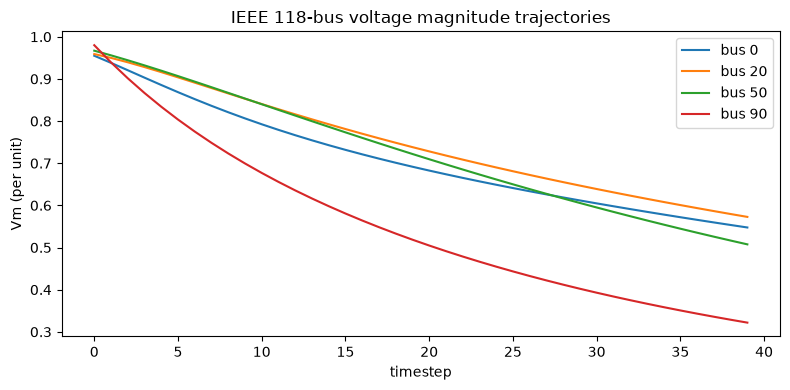

In [3]:
feature_idx = 0  # Vm
bus_ids = [0, 20, 50, 90]
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for bus_id in bus_ids:
    values = torch.stack([snap.x[bus_id, feature_idx] for snap in data_sequence])
    ax.plot(times, values.numpy(), label=f"bus {bus_id}")
ax.set_xlabel("timestep")
ax.set_ylabel("Vm (per unit)")
ax.set_title("IEEE 118-bus voltage magnitude trajectories")
ax.legend()
fig.tight_layout()
plt.show()

## Build the model

For voltage rollout we train on **Vm only**. The four bus features have very
different scales (Vm ≈ 1 p.u., Va in degrees, loads in per-unit MW/MVAr). A
joint model optimizes mostly angle errors, which hurts Vm trajectories. A
dedicated Vm model gives much better bus-by-bus voltage forecasts.

In [4]:
vm_sequence = GraphSnapshotSequence(
    [
        Data(x=snap.x[:, :1].clone(), edge_index=snap.edge_index)
        for snap in data_sequence
    ]
)

in_channels = 1
hidden_channels = 64
latent_dim = 64
out_channels = 1

# Seed before constructing modules so their initial weights are reproducible.
torch.manual_seed(0)
encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, out_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=0.1,
)

print(model)

GraphKoopmanModel(
  (encoder): GNNEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(1, 64)
      (1): GCNConv(64, 64)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 1)
    )
  )
  (koopman): KoopmanOperator()
)


## Train

`fit` optimizes one-step reconstruction, forward consistency, and an
autoregressive **rollout** term that matches `predict`. A stronger rollout
weight (`5.0`), longer training (`500` epochs), and gradient clipping improve
multi-step forecasts — especially the first predicted step, which is dominated
by one-step forward error rather than autoregressive drift.

In [5]:
predict_steps = 10
EPOCHS = 50 if os.environ.get("PYTEST_CURRENT_TEST") else 500
loss_weights = constant_loss_weights(
    reconstruction=1.0,
    forward=1.0,
    rollout=5.0,
)

history = model.fit(
    vm_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=predict_steps,
    max_grad_norm=1.0,
)

print(f"Initial loss: {history.loss[0]:.6f}")
print(f"Final loss: {history.loss[-1]:.6f}")

Initial loss: 3.323659
Final loss: 0.028039


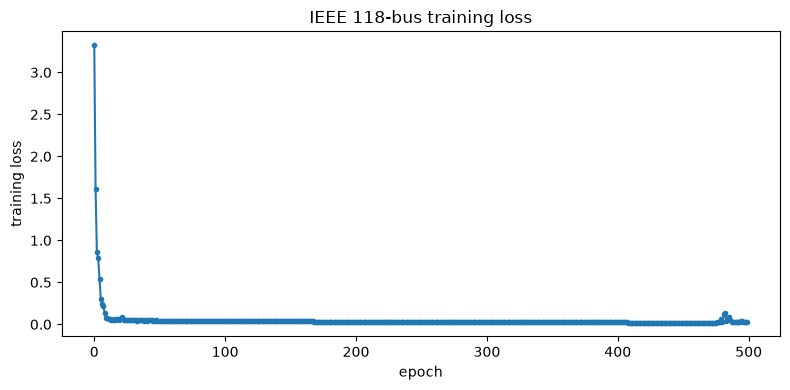

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.loss, marker="o", markersize=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("IEEE 118-bus training loss")
fig.tight_layout()
plt.show()

## Predict future snapshots

`predict` rolls out autoregressively in latent space and decodes after each step.

The first snapshot sits near the MATPOWER operating point (Vm ≈ 1 p.u.), where
the learned Koopman step tends to undershoot. For a clearer rollout demo we
start from snapshot `rollout_start` after voltages have diffused slightly;
one-step error is much smaller there while the multi-step trend stays similar.

The benchmark's voltage dynamics are known to be non-increasing, but the generic
Koopman model does not enforce that domain constraint or the observed decay rate.
We estimate a robust per-bus decay ratio from snapshots available before the
forecast, then cap each raw prediction by the previous constrained value times
that ratio. This uses only historical observations—never future ground truth.
Both raw and constrained errors are reported so the post-processing is explicit
rather than presented as learned behavior.

In [7]:
rollout_start = 5
initial_graph = vm_sequence[rollout_start]
raw_future_graphs = model.predict(initial_graph, steps=predict_steps)
raw_values = torch.stack([graph.x for graph in raw_future_graphs])

history_values = torch.stack(
    [vm_sequence[index].x for index in range(rollout_start + 1)]
)
historical_ratios = history_values[1:] / history_values[:-1]
decay_ratio = torch.median(historical_ratios, dim=0).values.clamp(max=1.0)

constrained_predictions = []
previous_values = initial_graph.x
for raw_prediction in raw_values:
    constrained_prediction = torch.minimum(
        raw_prediction,
        previous_values * decay_ratio,
    )
    constrained_predictions.append(constrained_prediction)
    previous_values = constrained_prediction
constrained_values = torch.stack(constrained_predictions)

future_graphs = []
for graph, values in zip(raw_future_graphs, constrained_values, strict=True):
    constrained_graph = graph.clone()
    constrained_graph.x = values
    future_graphs.append(constrained_graph)

print(f"Predicted {len(future_graphs)} snapshots from index {rollout_start}")
print(f"Prediction shape: {future_graphs[0].x.shape}")

ground_truth = vm_sequence[rollout_start + 1 : rollout_start + predict_steps + 1]
truth_values = torch.stack([graph.x for graph in ground_truth])
raw_mse = torch.mean((raw_values - truth_values) ** 2)
constrained_mse = torch.mean((constrained_values - truth_values) ** 2)
print(f"Raw rollout MSE vs held-in sequence: {raw_mse.item():.6f}")
print(f"History-constrained rollout MSE: {constrained_mse.item():.6f}")

Predicted 10 snapshots from index 5
Prediction shape: torch.Size([118, 1])
Raw rollout MSE vs held-in sequence: 0.006794
History-constrained rollout MSE: 0.001614


### Rollout quality across all buses

Check aggregate error before inspecting individual buses. The RMSE statistics
show forecast accuracy, direction agreement measures whether non-flat predictions
move with the truth, and monotonic compliance verifies the domain constraint
over every bus and forecast transition.

In [8]:
bus_rmse = []
direction_hits = 0
direction_total = 0

for bus_id in range(data_sequence.num_nodes):
    pred_values = torch.stack([graph.x[bus_id, 0] for graph in future_graphs])
    truth_values = torch.stack([graph.x[bus_id, 0] for graph in ground_truth])
    bus_rmse.append(torch.sqrt(torch.mean((pred_values - truth_values) ** 2)).item())

    for step in range(predict_steps - 1):
        pred_delta = pred_values[step + 1] - pred_values[step]
        truth_delta = truth_values[step + 1] - truth_values[step]
        if abs(truth_delta.item()) > 1e-4:
            direction_total += 1
            if pred_delta.item() * truth_delta.item() > 0:
                direction_hits += 1

constrained_steps = torch.diff(constrained_values[..., 0], dim=0)
monotonic_hits = int((constrained_steps <= 0).sum().item())
monotonic_total = constrained_steps.numel()

bus_rmse_tensor = torch.tensor(bus_rmse)
print(f"Median bus Vm RMSE: {bus_rmse_tensor.median().item():.4f}")
print(f"Mean bus Vm RMSE: {bus_rmse_tensor.mean().item():.4f}")
print(f"90th percentile bus Vm RMSE: {bus_rmse_tensor.quantile(0.9).item():.4f}")
print(
    f"Buses with RMSE < 0.10: "
    f"{int((bus_rmse_tensor < 0.10).sum().item())}/{data_sequence.num_nodes}"
)
print(
    f"Direction agreement: {direction_hits}/{direction_total} "
    f"({100.0 * direction_hits / max(direction_total, 1):.1f}%)"
)
print(
    f"Non-increasing transitions: {monotonic_hits}/{monotonic_total} "
    f"({100.0 * monotonic_hits / monotonic_total:.1f}%)"
)

Median bus Vm RMSE: 0.0306
Mean bus Vm RMSE: 0.0344
90th percentile bus Vm RMSE: 0.0637
Buses with RMSE < 0.10: 118/118
Direction agreement: 942/1061 (88.8%)
Non-increasing transitions: 1062/1062 (100.0%)


## Controlled dynamics with load-ramp inputs

The benchmark can expose the sinusoidal **load ramp** as an explicit exogenous
control $u_t$. With `control_dim=1`, the Koopman step becomes

$$z_{t+1} \approx z_t K^\top + u_t B,$$

which mirrors Koopman-with-control (DMDc) used in power-systems forecasting.
We also fit a classical **DMDc** baseline on flattened bus states for a quick
topology-agnostic comparison.

In [ ]:
from koopman_graph import DMDcBaseline

controlled_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=24,
    expose_load_ramp_control=True,
    seed=0,
)
controlled_vm = GraphSnapshotSequence(
    [Data(x=s.x[:, :1], edge_index=s.edge_index) for s in controlled_sequence]
)
controlled_vm = GraphSnapshotSequence(
    controlled_vm.snapshots,
    control_inputs=controlled_sequence.control_inputs,
)

controlled_encoder = GNNEncoder(
    in_channels=1,
    hidden_channels=32,
    latent_dim=16,
)
controlled_decoder = GNNDecoder(
    latent_dim=16,
    hidden_channels=32,
    out_channels=1,
)
controlled_model = GraphKoopmanModel(
    encoder=controlled_encoder,
    decoder=controlled_decoder,
    latent_dim=16,
    time_step=0.25,
    control_dim=1,
)

controlled_history = controlled_model.fit(
    controlled_vm,
    epochs=80,
    lr=1e-2,
    loss_weights=constant_loss_weights(reconstruction=1.0, forward=0.1),
)

dmdc = DMDcBaseline(time_step=0.25).fit(controlled_vm)

origin = 0
horizon = 6
future_controls = controlled_vm.rollout_controls(origin, horizon)
controlled_preds = controlled_model.predict(
    controlled_vm[origin],
    steps=horizon,
    controls=future_controls,
)
dmdc_preds = dmdc.predict(controlled_vm[origin], steps=horizon, controls=future_controls)

controlled_rmse = float(
    torch.sqrt(
        torch.mean(
            (controlled_preds[-1].x - controlled_vm[origin + horizon].x) ** 2
        )
    )
)
dmdc_rmse = float(
    torch.sqrt(
        torch.mean((dmdc_preds[-1].x - controlled_vm[origin + horizon].x) ** 2)
    )
)
print(f"Controlled GraphKoopman RMSE @ {horizon} steps: {controlled_rmse:.4f}")
print(f"DMDc baseline RMSE @ {horizon} steps: {dmdc_rmse:.4f}")
print(f"Training loss (final): {controlled_history.loss[-1]:.4f}")

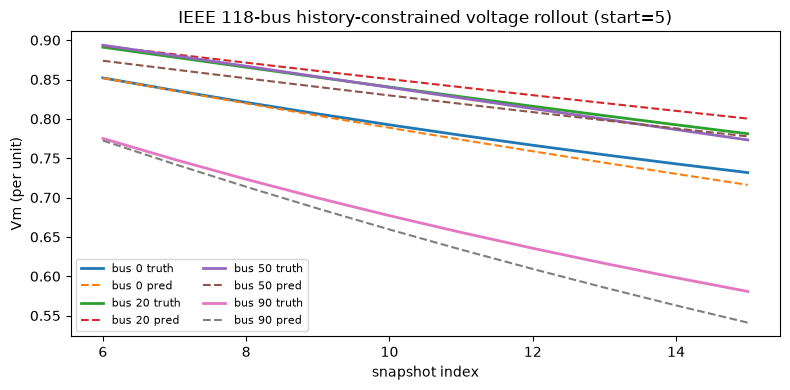

In [9]:
bus_ids = [0, 20, 50, 90]
pred_times = torch.arange(rollout_start + 1, rollout_start + predict_steps + 1)

fig, ax = plt.subplots(figsize=(8, 4))
for bus_id in bus_ids:
    truth_values = torch.stack(
        [graph.x[bus_id, 0] for graph in ground_truth]
    )
    pred_values = torch.stack([graph.x[bus_id, 0] for graph in future_graphs])
    ax.plot(pred_times, truth_values.numpy(), linewidth=2, label=f"bus {bus_id} truth")
    ax.plot(
        pred_times,
        pred_values.numpy(),
        linestyle="--",
        label=f"bus {bus_id} pred",
    )

ax.set_xlabel("snapshot index")
ax.set_ylabel("Vm (per unit)")
ax.set_title(
    f"IEEE 118-bus history-constrained voltage rollout (start={rollout_start})"
)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for a smaller
  synthetic graph walkthrough.
- **All four bus features:** z-score normalize each channel before training,
  or train separate models per quantity (Vm, Va, loads). Mixed-scale MSE
  without normalization usually favors angles over voltages.
- **Longer horizons:** increase `rollout_horizon` during training to match
  the number of prediction steps.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss weights, early stopping, and GAT encoders.
- See [`03_traffic_network.ipynb`](03_traffic_network.ipynb) for METR-LA traffic
  speed forecasting on a road sensor network.